In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold
from sklearn.metrics import classification_report,precision_score
from sklearn.ensemble import RandomForestClassifier

In [14]:
breast_cancer_data = load_breast_cancer(as_frame=True)

In [15]:
df = breast_cancer_data.frame

In [16]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [29]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [19]:
for x in range(11):
    X ,y = df.drop(columns=['target']),df['target']
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=x)
    y_pred = RandomForestClassifier().fit(X_train,y_train).predict(X_test)
    print(f' Random State : {x}')
    print(classification_report(y_test,y_pred))
    print()

 Random State : 0
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        47
           1       0.97      0.96      0.96        67

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


 Random State : 1
              precision    recall  f1-score   support

           0       0.97      0.88      0.93        42
           1       0.93      0.99      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114


 Random State : 2
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        45
           1       0.96      0.94      0.95        69

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.94       114
weighted avg      

In [20]:
# This shows how a single split is not trustworthy and the difference is caused by the split choosing different values for each random_state

In [21]:
# Now lets do this with a single classification metric lets say precision

In [24]:
for x in range(11):
    X ,y = df.drop(columns=['target']),df['target']
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=x)
    y_pred = RandomForestClassifier().fit(X_train,y_train).predict(X_test)
    print(f' Random State : {x}')
    print(precision_score(y_test,y_pred))
    print()

 Random State : 0
0.9696969696969697

 Random State : 1
0.9342105263157895

 Random State : 2
0.9558823529411765

 Random State : 3
0.9459459459459459

 Random State : 4
0.9861111111111112

 Random State : 5
0.9565217391304348

 Random State : 6
0.9344262295081968

 Random State : 7
0.9367088607594937

 Random State : 8
0.9444444444444444

 Random State : 9
0.9605263157894737

 Random State : 10
1.0



In [31]:
# Now we do kfolds for dividing our training set mostly intro further sets for training and validation set so we can get a better model
# There are many types of kfolds like : kfold,groupkfold,timeseriesssplit,stratifiedkfold
# Each serve a different purpose

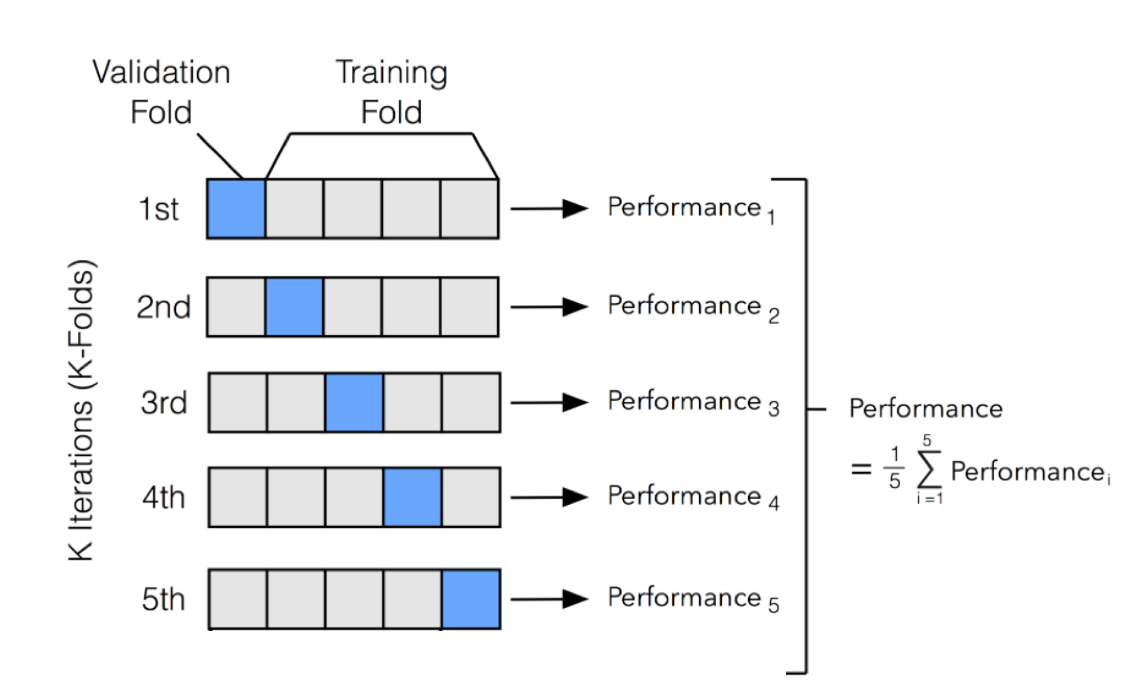

In [32]:
# A common misconception I had was that the validation fold is the test fold but it is wrong.
# Actually we use kfolds on the training set after splitting it using train_test_split and the testing set is the one specifically used for evaluation

In [33]:
# When we perform cross_val_score function on our training set inside we are performing stratifiedkfold for classification
# and kfold for regression all along.
# For other particular data we must use groupfold or timeseeriesplit explicitly

In [34]:
# Now we will do cross_val_score for the same 

In [39]:
X ,y = df.drop(columns=['target']),df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=x)
rfr = RandomForestClassifier()
rfr.fit(X_train,y_train)
cvs_rfr = cross_val_score(rfr,X_train,y_train,cv=StratifiedKFold(n_splits=5))
print(f'The Cross val mean : {cvs_rfr.mean()}')

The Cross val mean : 0.9582417582417582


In [ ]:
# What happened behind scenese was the spltting of the training set into 5 folds , we can directly pass the cross val folds 5 
# and it will by default select cv = StratifiedKFold